## Mvelo Khumalo
## ST10076452
### PDAN8411 POE PART 2

# Classification of a Cancer dataset

## What is classification

Classification models are a kind of predictive modelling that uses feature values to group data into predetermined groups. One kind of machine learning model that separates data points into pre-established groupings known as classes is the classification model. Classifiers are a kind of predictive modelling that uses input data to learn class characteristics and then uses those learnt features to assign potential classes to future data.1 In data science, classification algorithms are frequently used to predict events and forecast patterns. They do in fact have a wide range of practical applications, like patient categorisation based on possible health hazards (Kavlakoglu and Murel, 2026).

# Importing python libraries

In [95]:
!pip install seaborn

In [96]:
import numpy as np
import pandas as pd
from sklearn.preprocessing import MinMaxScaler
import seaborn as sns
import matplotlib.pyplot as plt
#This section is for building the model 
from sklearn.model_selection import cross_val_score, train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import r2_score, mean_absolute_error

# Importing the dataset

We are importing the dataset which is in CSV format and using the dataset.info to display the data making it easier to view the column names and how many data entries there are in the dataset.

In [97]:
dataset = pd.read_csv('crc_dataset.csv')
dataset.info()
print(dataset.head())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 15 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Participant_ID           1000 non-null   int64  
 1   Age                      1000 non-null   int64  
 2   Gender                   1000 non-null   object 
 3   BMI                      1000 non-null   float64
 4   Lifestyle                1000 non-null   object 
 5   Ethnicity                1000 non-null   object 
 6   Family_History_CRC       1000 non-null   object 
 7   Pre-existing Conditions  762 non-null    object 
 8   Carbohydrates (g)        1000 non-null   int64  
 9   Proteins (g)             1000 non-null   int64  
 10  Fats (g)                 1000 non-null   int64  
 11  Vitamin A (IU)           1000 non-null   int64  
 12  Vitamin C (mg)           1000 non-null   int64  
 13  Iron (mg)                1000 non-null   float64
 14  CRC_Risk                 

# Cleaning the dataset

The dataset will be wrangled accordingly removing duplicates, Null values, outliers and inconsistent data inputs within the rows of the dataset.
The process of preparing raw data for analysis by identifying and fixing problems is known as data cleaning. This fundamental stage of data preparation guarantees that datasets are appropriate for tasks including analysis, statistics, and machine learning.

In [98]:
dataset.duplicated
cat_col = [col for col in dataset.columns if dataset[col].dtype == 'object']
num_col = [col for col in dataset.columns if dataset[col].dtype != 'object']

print('Categorical columns:', cat_col)
print('Numerical columns:', num_col)

Categorical columns: ['Gender', 'Lifestyle', 'Ethnicity', 'Family_History_CRC', 'Pre-existing Conditions']
Numerical columns: ['Participant_ID', 'Age', 'BMI', 'Carbohydrates (g)', 'Proteins (g)', 'Fats (g)', 'Vitamin A (IU)', 'Vitamin C (mg)', 'Iron (mg)', 'CRC_Risk']


Now that the data has been arranged by the categorical and numerical columns we can ascertain if there are unique values per column within the dataset.

In [99]:
dataset[cat_col].nunique()

Gender                     2
Lifestyle                  4
Ethnicity                  4
Family_History_CRC         2
Pre-existing Conditions    3
dtype: int64

Dropping a column just to make the dataset easier to handle, we will drop the participant ID as it creates noise in the dataset which can disrupt the analysis so it was a column that needed to be dropped to ensure our analysis was as accurate as possible.

In [100]:
dataset1 = dataset.drop(columns=['Participant_ID'])
print(dataset1.head())

   Age  Gender   BMI          Lifestyle Ethnicity Family_History_CRC  \
0   63  Female  21.6          Sedentary  Hispanic                Yes   
1   76    Male  31.4             Smoker  Hispanic                 No   
2   53  Female  24.3  Moderate Exercise     Asian                 No   
3   39    Male  19.5          Sedentary     Asian                Yes   
4   67    Male  34.5  Moderate Exercise     Asian                 No   

  Pre-existing Conditions  Carbohydrates (g)  Proteins (g)  Fats (g)  \
0                Diabetes                245            98        41   
1                 Obesity                398            56        61   
2                     NaN                375            79        59   
3                     NaN                325            98        64   
4                 Obesity                169            65        54   

   Vitamin A (IU)  Vitamin C (mg)  Iron (mg)  CRC_Risk  
0            4176              97       15.3         0  
1            3400   

Finding the duplicates

In [101]:
duplicates = dataset1[dataset1.duplicated()]
print(duplicates)

Empty DataFrame
Columns: [Age, Gender, BMI, Lifestyle, Ethnicity, Family_History_CRC, Pre-existing Conditions, Carbohydrates (g), Proteins (g), Fats (g), Vitamin A (IU), Vitamin C (mg), Iron (mg), CRC_Risk]
Index: []


We can now see that the data is clean with no duplicates and the participant ID column dropped to make the analysis easier to conduct the analysis.

# Encoding the data

We have categorical and numerical data in the dataset with the CRC_Risk already encoded to a 0 and 1 value for yes and no. The other columns have not been encoded like the gender, lifestyle, ethnicty, family history, and pre existing conditions. These categories will be encoded to match the numerical values to make the model. 

In [102]:
print(f"Original CRC Data:\n{dataset1}\n")

# For the gender we will use simple binary encoding

dataset1['Gender'] = dataset1['Gender'].map({'Female': 0, 'Male': 1})
dataset1['Family_History_CRC'] = dataset1['Family_History_CRC'].map({'No': 0, 'Yes': 1})

# Cardinal nominal columns are encoded
dataset1['Pre-existing Conditions'] = dataset1['Pre-existing Conditions'].fillna('None')
dataset1_encoded = pd.get_dummies(dataset1, columns=['Lifestyle', 'Ethnicity', 'Pre-existing Conditions'], drop_first=True,dtype=int)

# We are now scaling the numerical features
numerical_cols = ['Age', 'BMI', 'Carbohydrates (g)', 'Proteins (g)', 'Fats (g)', 'Vitamin A (IU)', 'Vitamin C (mg)', 'Iron (mg)']
scaler = StandardScaler()
dataset1_encoded[numerical_cols] = scaler.fit_transform(dataset1_encoded[numerical_cols])

print(f"Encoded Data using Pandas and scaler:\n{dataset1_encoded}\n")

Original CRC Data:
     Age  Gender   BMI          Lifestyle         Ethnicity  \
0     63  Female  21.6          Sedentary          Hispanic   
1     76    Male  31.4             Smoker          Hispanic   
2     53  Female  24.3  Moderate Exercise             Asian   
3     39    Male  19.5          Sedentary             Asian   
4     67    Male  34.5  Moderate Exercise             Asian   
..   ...     ...   ...                ...               ...   
995   56    Male  21.9  Moderate Exercise  African American   
996   27  Female  27.1  Moderate Exercise  African American   
997   51    Male  23.2             Smoker             Asian   
998   53  Female  31.6             Active  African American   
999   56    Male  28.0             Smoker             Asian   

    Family_History_CRC Pre-existing Conditions  Carbohydrates (g)  \
0                  Yes                Diabetes                245   
1                   No                 Obesity                398   
2                

 # Univariate analysis : The distribution plot

The most basic type of data analysis is univariate analysis. Since "uni" means "one," there is just one variable in your data. Its main goal is to describe; unlike regression, it does not address causes or links; It gathers data, condenses it, and looks for trends. In this section a distribution plot will be implemented to conduct the distribution between categories.

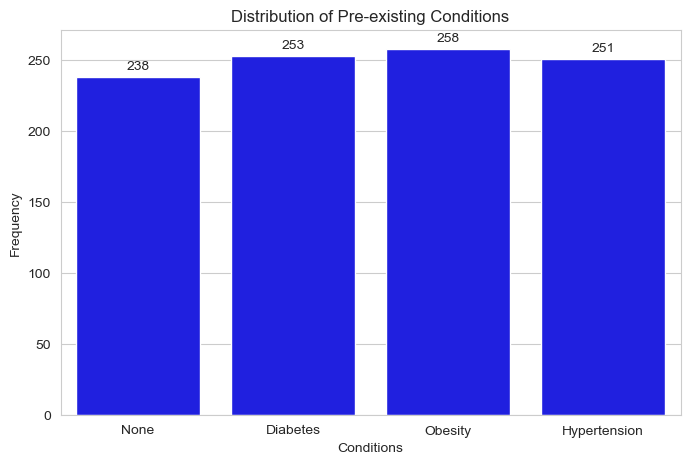

In [103]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.set_style('whitegrid')
plt.figure(figsize=(8, 5))

# Use countplot for categorical data
ax = sns.countplot(
    data=dataset1, 
    x='Pre-existing Conditions', 
    color='Blue',
     order=['None', 'Diabetes', 'Obesity', 'Hypertension']
)


ax.bar_label(ax.containers[0], padding=3)
plt.title('Distribution of Pre-existing Conditions')
plt.xlabel('Conditions')
plt.ylabel('Frequency')
plt.show()

The distribution of the Pre-existing conditions are as such that there is more individuals with obesity then diabetes, hypertension then individuals with no pre-existing conditions follow. This is the visual representation of the frequency of a condition between individuals who participated in the analysis on if they have a pre existing condition that can increase the risk of CRC.

# Distribution of BMI

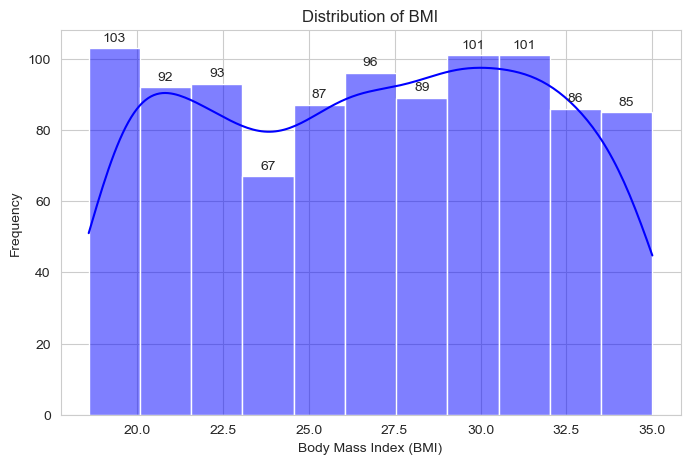

In [104]:
plt.figure(figsize=(8, 5))

# Plotting BMI
ax = sns.histplot(dataset1['BMI'], kde=True, color='blue')

ax.bar_label(ax.containers[0], padding=3)
plt.title('Distribution of BMI')
plt.xlabel('Body Mass Index (BMI)')
plt.ylabel('Frequency')
plt.show()

This substantial distribution in higher BMI categories indicates a significantly heightened risk profile for a significant portion of this group in terms of colorectal cancer (CRC) risk. Clinically, excess adiposity causes systemic biological changes that actively promote tumour cell proliferation and angiogenesis in colon tissue. These alterations include chronic low-grade inflammation, insulin resistance that raises free IGF-1 levels, and altered adipokine secretions. Therefore, if BMI is used in a classification pipeline for CRC risk, it will probably function as a very significant predictive feature with a substantial positive coefficient due to the strong dose-response association between body mass and carcinogenesis.

# Distribution of Ages

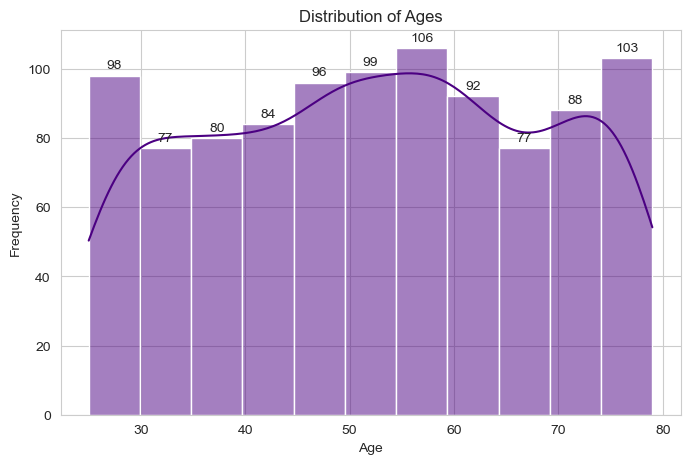

In [105]:
plt.figure(figsize=(8, 5))

# Plotting BMI
ax = sns.histplot(dataset1['Age'], kde=True, color='indigo')

ax.bar_label(ax.containers[0], padding=3)
plt.title('Distribution of Ages')
plt.xlabel('Age')
plt.ylabel('Frequency')
plt.show()

The age distribution of the cohort, according to the given histogram, ranges from around 25 to 80 years old, indicating a fundamentally mature adult population with significant density across all age groups. With a maximum bin count of 106 between the ages of 50 and 60 and another large rise in the late 70s (103 people), the distribution exhibits a notable concentration in the middle-aged and older sectors. Since the incidence of colorectal cancer (CRC) increases dramatically after age 50 due to the time-dependent accumulation of somatic genetic mutations, prolonged exposure to environmental risk factors, this demographic profile places a significant portion of the dataset within the clinically recognized high-risk window in the context of CRC risk analysis.

# Detecting outliers

A data point that substantially differs from other observations in a dataset is called an outlier. Outliers are simply statistical anomalies. If they are not properly managed, outliers—which can result from measurement mistakes, natural variation, or uncommon occurrences—can have a disproportionate effect on statistical studies and machine learning models.

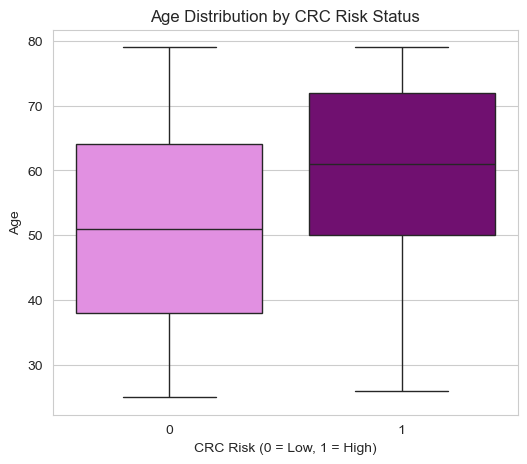

In [106]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(6, 5))
sns.set_style('whitegrid')

custom_colors = {0: "Violet", 1: "Purple"}

sns.boxplot(data=dataset1, x='CRC_Risk', y='Age', hue='CRC_Risk', palette=custom_colors, legend=False)

plt.title('Age Distribution by CRC Risk Status')
plt.xlabel('CRC Risk (0 = Low, 1 = High)')
plt.ylabel('Age')
plt.show()

The upward movement in the overall distribution for the high-risk group (1) relative to the low-risk group (0) in the box plot indicates a definite, positive correlation between increasing age and greater Colorectal Cancer (CRC) risk status. The high-risk cohort's median age rises dramatically to over 61 years old, whereas the median age for low-risk people is around 51. Additionally, the low-risk box covers a younger demographic from around 38 to 64 years old, while the high-risk individuals are densely packed between roughly 50 and 72 years old, according to the interquartile range (IQR), which represents the middle 50% of the data. 

# Box plot for metabolic risks

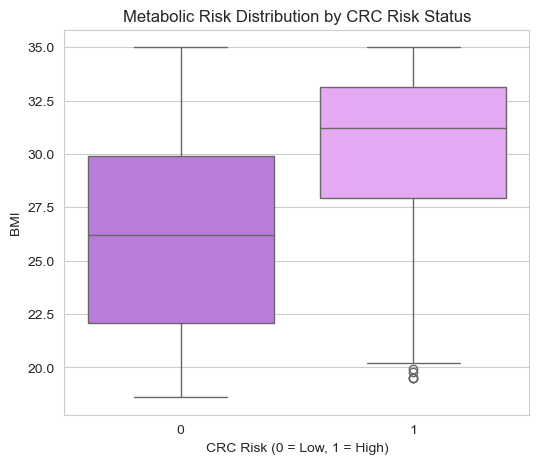

In [107]:
plt.figure(figsize=(6, 5))
sns.set_style('whitegrid')

custom_colors = {0: "#c06ceb", 1: "#ed9cff"}

sns.boxplot(data=dataset1, x='CRC_Risk', y='BMI', hue='CRC_Risk', palette=custom_colors, legend=False)

plt.title('Metabolic Risk Distribution by CRC Risk Status')
plt.xlabel('CRC Risk (0 = Low, 1 = High)')
plt.ylabel('BMI')
plt.show()

The box plot shows a significant upward shift in the BMI distribution for the high-risk group, indicating a strong, positive correlation between raised Body Mass Index (BMI) and high Colorectal Cancer (CRC) risk status (1). While the high-risk group's median BMI climbs dramatically to nearly 31.2, putting over half of that cohort firmly in the clinically obese category, the low-risk group's median BMI (0) is at a healthy-to-overweight threshold of roughly 26.2. 

# Odds Ratios Bar Chart

In observational studies or trials, the odd ratio (OR) is a statistical term used to quantify the direction and intensity of a link between two variables. The odds ratio contrasts the likelihood that an event will occur in one group with the likelihood that it will occur in another. It is the ratio of the likelihood that an event will occur in one group to the likelihood that it will occur in another. In fields including epidemiology, medicine, psychology, and the social sciences, it is frequently used to assess how likely an outcome is to occur in one group as opposed to another(GeeksforGeeks,2025)

In [108]:
contingency_table = pd.crosstab(dataset1['Lifestyle'], dataset1['CRC_Risk'])
print(contingency_table)

A = contingency_table.loc['Smoker', 1]      # Smokers with CRC Risk
B = contingency_table.loc['Smoker', 0]      # Smokers with Low Risk
C = contingency_table.loc['Sedentary', 1]    # Baseline with CRC Risk
D = contingency_table.loc['Sedentary', 0]    # Baselinee with low risk

odds_ratio = (A*D) / (B*C)
print(f"Odds ratio for smoker vs sedentary: {odds_ratio:.2}")

CRC_Risk             0   1
Lifestyle                 
Active             206  24
Moderate Exercise  240  21
Sedentary          243  15
Smoker             156  95
Odds ratio for smoker vs sedentary: 9.9


By utilizing a sedentary lifestyle as the baseline reference group and computing an odds ratio to identify the precise effect of smoking on the risk of colorectal cancer (CRC). The calculated odds ratio of 9.9 shows that compared to sedentary people, smokers have a staggering 9.9 times greater odds of being in the high CRC risk category. According to the raw contingency table, this enormous risk gap is caused by the fact that just around 6% of sedentary people (15 out of 258) belong to the high-risk category, compared to approximately 38% of smokers (95 out of 251).

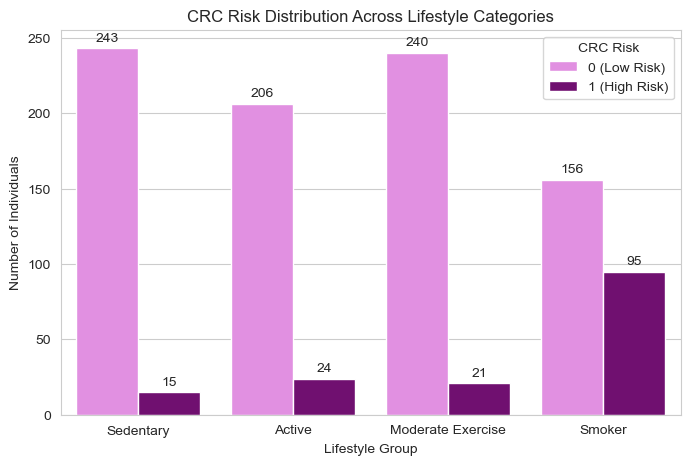

In [109]:
plt.figure(figsize=(8, 5))
sns.set_style('whitegrid')

ax = sns.countplot(data=dataset1, x='Lifestyle', hue='CRC_Risk', palette={0: "violet", 1: "purple"},order=['Sedentary', 'Active', 'Moderate Exercise', 'Smoker'])

for container in ax.containers:
    ax.bar_label(container, padding=3)

plt.title('CRC Risk Distribution Across Lifestyle Categories')
plt.xlabel('Lifestyle Group')
plt.ylabel('Number of Individuals')
plt.legend(title='CRC Risk', labels=['0 (Low Risk)', '1 (High Risk)'])
plt.show()

The grouped bar chart highlights "Smoker" as the most important risk category and offers a visual diagnostic comparison of the distribution of colorectal cancer (CRC) risk across several lifestyle categories. The majority of people in the "Sedentary," "Active," and "Moderate Exercise" groups are categorized as low risk (0), with high-risk (1) occurrences being incredibly rare between 15 and 24 people each category. Compared to all other lifestyle choices, the "Smoker" category shows a sharp increase in high-risk instances, reaching 95 persons and capturing a much larger percentage of high-risk to low-risk cases.

# ROC Curve

A graph called the AUC-ROC curve is used to assess the performance of a binary classification model. It aids in our comprehension of how well the model distinguishes between positive instances, such as those who have an illness, and negative cases, such as those who do not, at various threshold levels. Plotting demonstrates how well the model distinguishes between the two classes:
True Positive Rate (TPR), sometimes referred to as Sensitivity or Recall, is the frequency with which the model accurately predicts positive cases.
The frequency with which the model mispredicts a negative case as positive is known as the False Positive Rate (FPR).
Specificity: Calculates the percentage of real negatives that the model accurately detects. It is computed as 1-FPR (GeeksforGeeks, 2026).

In [110]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import roc_curve, auc

We have imported the train test split and logistic regression import from sklearn

## 80/20 Train test split

In [111]:
from sklearn.model_selection import train_test_split

X = dataset1_encoded.drop(columns=['CRC_Risk'])  

# I am isolating the target variable which is the CRC risk.
y = dataset1_encoded['CRC_Risk']                 

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42,stratify=y)

print(f"Training set size: {X_train.shape[0]} rows")
print(f"Testing set size: {X_test.shape[0]} rows")

Training set size: 800 rows
Testing set size: 200 rows


In [112]:
logistic_model = LogisticRegression(random_state=42)
logistic_model.fit(X_train, y_train)

random_forest_model = RandomForestClassifier(n_estimators=100, random_state=42)
random_forest_model.fit(X_train, y_train)

,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


By training a Random Forest Classifier with random_state=42 for reproducibility and a baseline Logistic Regression model using an 80/20 train-test split, which produced 800 training rows and 200 testing rows. Fitting the RandomForestClassifier with n_estimators=100 creates an ensemble of 100 independent decision trees for CRC risk prediction. Each tree is trained on a bootstrap sample of the training data and divides nodes according to a random subset of features (such as age, BMI, and encoded lifestyle factors).

In [113]:
from sklearn.metrics import classification_report, roc_auc_score

#  predictions on the test set
log_preds = logistic_model.predict(X_test)
rf_preds = random_forest_model.predict(X_test)

# probability scores (needed for calculating AUC)
log_probs = logistic_model.predict_proba(X_test)[:, 1]
rf_probs = random_forest_model.predict_proba(X_test)[:, 1]

# Print the performance metrics
print("=== LOGISTIC REGRESSION REPORT ===")
print(classification_report(y_test, log_preds))
print(f"Logistic AUC Score: {roc_auc_score(y_test, log_probs):.4f}\n")

print("=== RANDOM FOREST REPORT ===")
print(classification_report(y_test, rf_preds))
print(f"Random Forest AUC Score: {roc_auc_score(y_test, rf_probs):.4f}")

=== LOGISTIC REGRESSION REPORT ===
              precision    recall  f1-score   support

           0       0.90      0.96      0.93       169
           1       0.65      0.42      0.51        31

    accuracy                           0.88       200
   macro avg       0.78      0.69      0.72       200
weighted avg       0.86      0.88      0.86       200

Logistic AUC Score: 0.9091

=== RANDOM FOREST REPORT ===
              precision    recall  f1-score   support

           0       0.89      1.00      0.94       169
           1       1.00      0.35      0.52        31

    accuracy                           0.90       200
   macro avg       0.95      0.68      0.73       200
weighted avg       0.91      0.90      0.88       200

Random Forest AUC Score: 0.9501


According to the classification reports, both models struggle greatly with class imbalance when predicting the minority high-risk CRC category (Class 1, support: 31), despite achieving strong Area Under the Curve scores (Logistic AUC: 0.9091, Random Forest AUC: 0.9501) and high overall accuracy (Logistic Regression: 88%, Random Forest: 90%). The Random Forest Classifier has a severely poor recall of 0.35, missing 65% of real high-risk individuals, but it achieves perfect accuracy (1.00) for Class 1, meaning it produces zero false positives. Despite having a lower accuracy of 0.65, the Logistic Regression model offers a marginally better balance for clinical risk screening, catching more high-risk patients with a higher recall of 0.42. The poor minority F1-scores (0.51 and 0.52) indicate that both pipelines need optimisation, such as threshold adjustment or class weighting, before deployment in a clinical setting where missing a high-risk diagnosis (a false negative) carries serious consequences. Nevertheless, the high AUC scores ultimately indicate strong overall discriminative potential.

## Plotting the ROC Curve

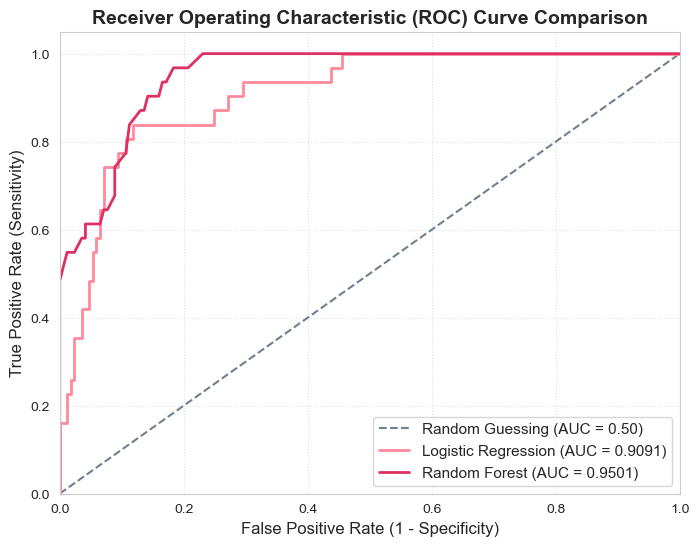

In [114]:
# The predicted probabilities for the positive class
log_probs = logistic_model.predict_proba(X_test)[:, 1]
rf_probs = random_forest_model.predict_proba(X_test)[:, 1]

# Calculation of the True Positive and False Positive for both models
fpr_log, tpr_log, _ = roc_curve(y_test, log_probs)
fpr_rf, tpr_rf, _ = roc_curve(y_test, rf_probs)

auc_log = auc(fpr_log, tpr_log)
auc_rf = auc(fpr_rf, tpr_rf)

plt.figure(figsize=(8, 6))
plt.plot([0, 1], [0, 1], color='slategrey', linestyle='--', label='Random Guessing (AUC = 0.50)')

plt.plot(fpr_log, tpr_log, color='#FF8A9D', linewidth=2, label=f'Logistic Regression (AUC = {auc_log:.4f})')
plt.plot(fpr_rf, tpr_rf, color='#DE3163', linewidth=2, label=f'Random Forest (AUC = {auc_rf:.4f})')

plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate (1 - Specificity)', fontsize=12)
plt.ylabel('True Positive Rate (Sensitivity)', fontsize=12)
plt.title('Receiver Operating Characteristic (ROC) Curve Comparison', fontsize=14, fontweight='bold')
plt.legend(loc="lower right", fontsize=11, frameon=True)
plt.grid(True, linestyle=':', alpha=0.6)

plt.show()

The results of the curve are that the ROC curve comparison shows that both models perform much better than the random guessing baseline (AUC = 0.50) and have great overall discriminative performance for CRC risk categorisation. With an Area Under the Curve (AUC) of 0.9501, the Random Forest Classifier outperforms the Logistic Regression model (AUC = 0.09091) and maintains a consistently better True Positive Rate (Sensitivity) across nearly all False Positive Rate thresholds. The Random Forest curve visually bends significantly closer to the plot's upper-left corner, demonstrating how well its ensemble design maximises actual danger recognition while reducing false alarms.

# Precision recall curve

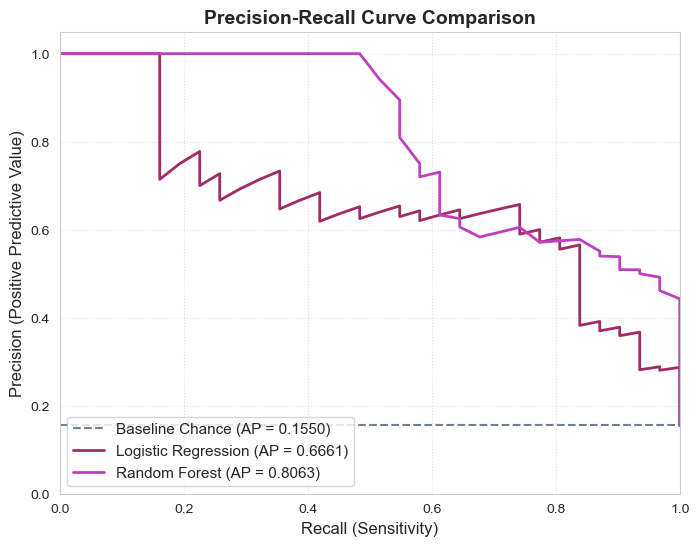

In [115]:
from sklearn.metrics import precision_recall_curve, average_precision_score

precision_log, recall_log, _ = precision_recall_curve(y_test, log_probs)
precision_rf, recall_rf, _ = precision_recall_curve(y_test, rf_probs)

# Calculate Average Precision which serves as the score for the curve
ap_log = average_precision_score(y_test, log_probs)
ap_rf = average_precision_score(y_test, rf_probs)

plt.figure(figsize=(8, 6))

# Plot the baseline
baseline = 31 / 200
plt.axhline(y=baseline, color='slategrey', linestyle='--', label=f'Baseline Chance (AP = {baseline:.4f})')

plt.plot(recall_log, precision_log, color='#9F2B68', linewidth=2, label=f'Logistic Regression (AP = {ap_log:.4f})')
plt.plot(recall_rf, precision_rf, color='#BF40BF', linewidth=2, label=f'Random Forest (AP = {ap_rf:.4f})')

plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('Recall (Sensitivity)', fontsize=12)
plt.ylabel('Precision (Positive Predictive Value)', fontsize=12)
plt.title('Precision-Recall Curve Comparison', fontsize=14, fontweight='bold')
plt.legend(loc="lower left", fontsize=11, frameon=True)
plt.grid(True, linestyle=':', alpha=0.6)

plt.show()

Given the underlying class imbalance in the CRC dataset, the accuracy-Recall Curve comparison serves as a more diagnostic performance indicator than the ROC curve by highlighting how both pipelines handle the trade-off between accuracy and recall. The Random Forest Classifier has stronger predictive performance with a much higher Average Precision (AP) of 0.8063 compared to Logistic Regression's AP of 0.6661, even though both models perform significantly better than the baseline chance of an AP of 0.1550. The Random Forest curve can effectively categorise half of the high-risk people without producing a single false positive, as evidenced by its ability to retain perfect accuracy (1.0) throughout a significantly larger window of recall up to around 0.5.

# The Confusion matrix heatmap

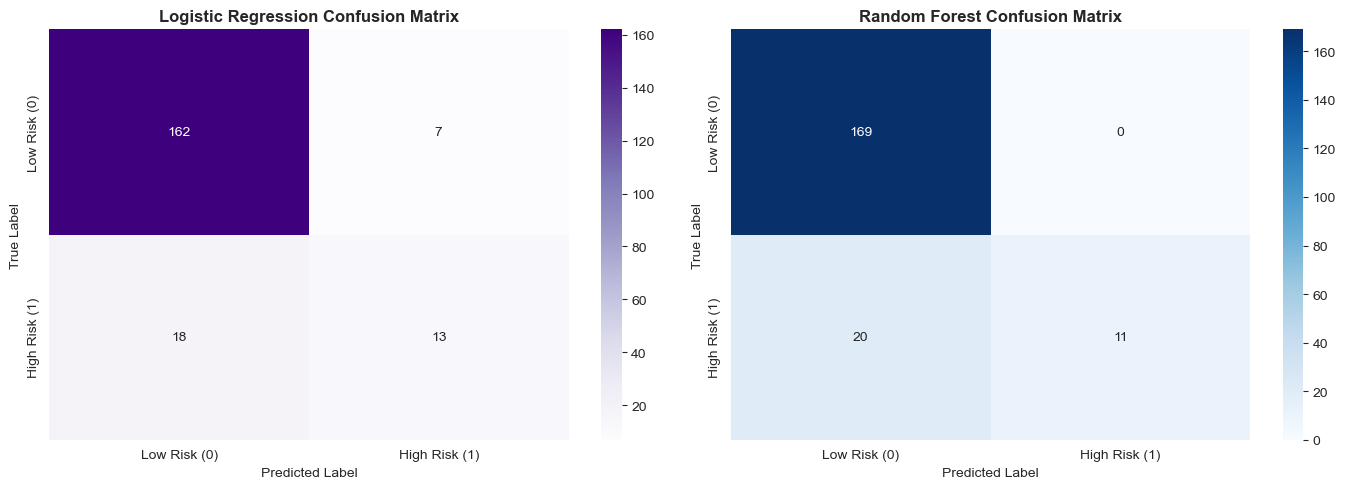

In [116]:
from sklearn.metrics import confusion_matrix


cm_log = confusion_matrix(y_test, log_preds)
cm_rf = confusion_matrix(y_test, rf_preds)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.heatmap(
    cm_log, 
    annot=True,fmt='d',  cmap='Purples', ax=axes[0],xticklabels=['Low Risk (0)', 'High Risk (1)'],yticklabels=['Low Risk (0)', 'High Risk (1)'])

axes[0].set_title('Logistic Regression Confusion Matrix', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Predicted Label')
axes[0].set_ylabel('True Label')

sns.heatmap(
    cm_rf, 
    annot=True, 
    fmt='d', 
    cmap='Blues',     
    ax=axes[1],
    xticklabels=['Low Risk (0)', 'High Risk (1)'],
    yticklabels=['Low Risk (0)', 'High Risk (1)']
)
axes[1].set_title('Random Forest Confusion Matrix', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Predicted Label')
axes[1].set_ylabel('True Label')

plt.tight_layout()
plt.show()

The confusion matrices show how both models manage the test set's 31 high-risk (Class 1) and 169 low-risk (Class 0) people by offering a straightforward, count-based diagnostic breakdown of true vs. anticipated classifications. With a perfect zero false-positive rate by correctly identifying all 169 low-risk individuals, the Random Forest Classifier exhibits an aggressive conservative bias toward the majority class. However, it generates 20 false negatives, missing approximately 65% of the real high-risk cohort and correctly predicting only 11. On the other hand, in a clinical screening setting, the Logistic Regression model works marginally better by obtaining 13 genuine positives and cutting the number of false negatives to 18, but at the expense of 7 false positives. In the end, the high number of false negatives in both matrices shows that, although Random Forest is statistically cleaner for low-risk identification, both pipelines strongly favour the majority class and necessitate class-weight tuning or threshold adjustments to safely reduce the clinical risk of overlooking high-risk CRC patients.

# Predicted probability graph 

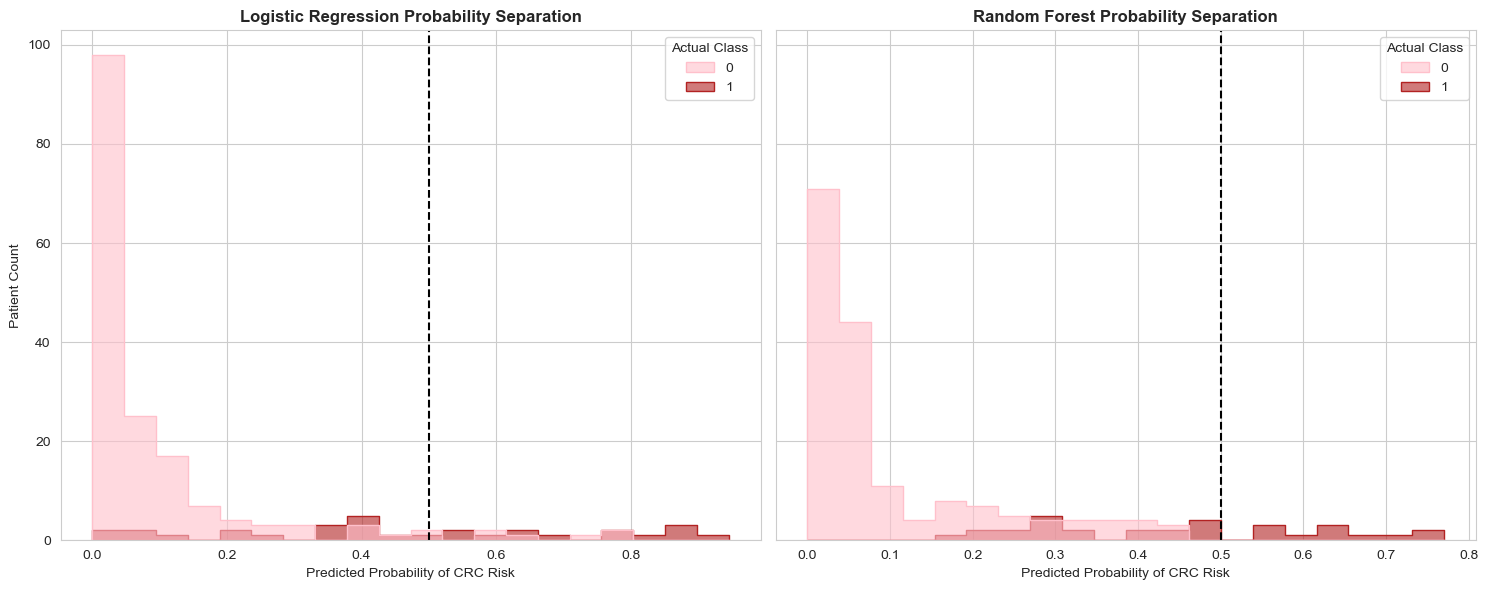

In [117]:
fig, axes = plt.subplots(1, 2, figsize=(15, 6), sharey=True)

# pink for healthy (0), Crimson for risk (1)
colors = {0: "Pink", 1: "#B22222"}

# Logistic regression
sns.histplot(x=log_probs,hue=y_test,element="step",stat="count",common_norm=False,palette=colors,alpha=0.6,bins=20,ax=axes[0])

axes[0].axvline(x=0.5, color='black', linestyle='--', linewidth=1.5)
axes[0].set_title('Logistic Regression Probability Separation', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Predicted Probability of CRC Risk')
axes[0].set_ylabel('Patient Count')
axes[0].get_legend().set_title("Actual Class")

# Random Forest Separation
sns.histplot(x=rf_probs,hue=y_test,element="step",stat="count",common_norm=False,palette=colors,alpha=0.6,bins=20,ax=axes[1])

axes[1].axvline(x=0.5, color='black', linestyle='--', linewidth=1.5)
axes[1].set_title('Random Forest Probability Separation', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Predicted Probability of CRC Risk')
axes[1].get_legend().set_title("Actual Class")

plt.tight_layout()
plt.show()

The great majority of actual low-risk individuals (Actual Class 0, shown in light pink) are accurately and strongly grouped near a projected chance of 0.0 for both Random Forest and Logistic Regression, indicating significant confidence in detecting true negatives. But instead of forming a clear, distinct peak above the 0.5 decision boundary, the true high-risk individuals have probabilities that are widely distributed throughout the whole spectrum, with a significant number of true high-risk cases pooling just below the dashed threshold line. Although both classifiers are quite good at separating baseline low-risk individuals, this overlapping distribution shows that their decision limits are presently to properly capture the dark red occurrences that are now incorrectly labelled as low risk, the classification threshold must be shifted downward because it is not optimised for the minority class.

# Sigmoid Curve

A mathematical function called the sigmoid converts every real-valued integer into a value between 0 and 1. It is very helpful in situations when we need to transform outputs into probabilities because of its distinctive "S"-shaped curve. The logistic function is a common name for this function (GeeksforGeeks, 2025).

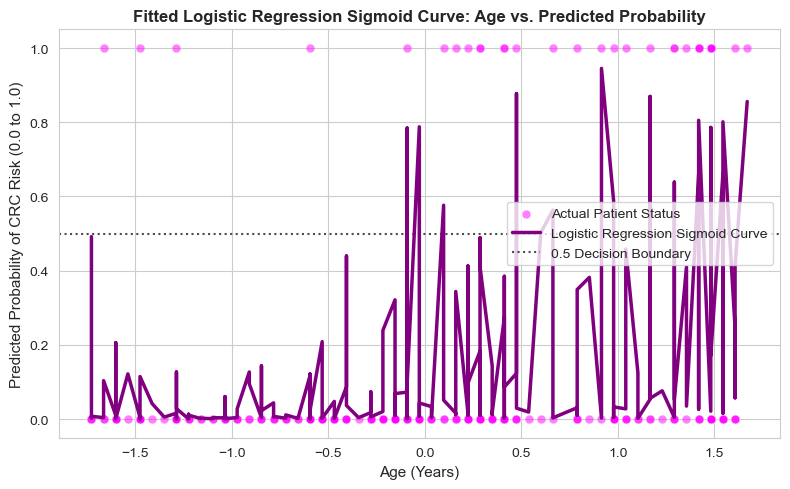

In [118]:
plt.figure(figsize=(8, 5))
sns.set_style('whitegrid')

# Scatter plot the actual data points 
sns.scatterplot(x=X_test['Age'], y=y_test, color='Magenta', alpha=0.5, s=40, label='Actual Patient Status',zorder=2)

# Plot the model's fitted Sigmoid probability curve

sort_idx = np.argsort(X_test['Age'])
plt.plot(X_test['Age'].iloc[sort_idx], log_probs[sort_idx], color='Purple', linewidth=2.5, label='Logistic Regression Sigmoid Curve',zorder=3)

# the critical 0.5 decision threshold
plt.axhline(y=0.5, color='black', linestyle=':', alpha=0.7, label='0.5 Decision Boundary')

plt.title('Fitted Logistic Regression Sigmoid Curve: Age vs. Predicted Probability', fontsize=12, fontweight='bold')
plt.xlabel('Age (Years)', fontsize=11)
plt.ylabel('Predicted Probability of CRC Risk (0.0 to 1.0)', fontsize=11)
plt.ylim(-0.05, 1.05)
plt.legend(loc='center right', frameon=True)
plt.tight_layout()

plt.show()

Plotting a multi-feature model against a single independent variable results in a very erratic line, as seen by the visualisation, which shows the fitted logistic regression probability curve versus age. People of the exact same age show wildly different predicted probabilities based on their different lifestyle metrics because the horizontal axis plots standardised age (roughly -1.7 to +1.7 standard deviations) while the model computes probabilities based on a combination of all encoded features (such as BMI and smoking status). Visually, the baseline probability floor stays low as age rises from negative to positive standard deviations, but the number and severity of upward spikes that cross the 0.5 decision threshold greatly increase. This distribution demonstrates that although growing older is a potent catalyst that increases the expected likelihood of having a high risk of colorectal cancer (Class 1), it does not act alone; rather, the model depends on the interaction of several characteristics to raise a patient's classification.

## Why logistic regression worked as the classification algorithm

Because logistic regression is mathematically built for binary classification and uses the logistic sigmoid function to map any combination of continuous dietary intakes and one-hot encoded lifestyle factors into a clear risk probability score between 0 and 1, it performed remarkably well for this analysis. We created a clear, linearly separable feature space where the model could draw a very solid decision boundary by converting our categorical parameters into independent binary features and standardising the continuous numerical columns using StandardScaler. Additionally, Logistic Regression was structurally perfect for our 1,000-instance sample size as a constrained parametric model, capturing robust predictive health patterns with high precision and recall while avoiding the serious overfitting risks associated with more intricate, non-linear machine learning architectures.